# HORSE, Simulation, and Bayesian Decision Analysis

The goal of this project is to:
1. Model the basketball game HORSE
2. Select shots that maximize the likelihood of winning, given unknown success rates
3. Compare shot-selection strategy by optimality, robustness, and computational feasibility

To accomplish these goals, we'll use Bayesian Inference, Multi-armed Bandits, Simulation, Hierarchical Modeling, and Robustness Analysis.

## Introduction

The rules of HORSE are simple. When it's your turn, you shoot the ball until you miss, each time you succeed, your opponent has to attempt the same shot. If your opponent fails, they get a letter. This process repeats until either you or you opponent loses by getting 5 letters: H, O, R, S, and E.

You can play with different sets of rules and numbers of players, but to keep it simple, we’ll only consider a 1v1 matchup with make-it-take-it-rules, which means if you make the shot, you get the ball back whether your opponent makes it or not.

We'll start with a simple model of the game and gradually layer in nuance throughout this notebook.

## Model 1: Known Probabilities

The only thing you get to decide during HORSE is which shot to attempt when it’s your turn to pick. Fundamentally, this whole decision is about striking a balance between the likelihood of you making it and the likelihood of your opponent making it.

Assuming you know both your and your opponent's probability of making a shot, the likelihood of a given shot successfully inflicting a letter during your turn can be solved with the following formula:

$$
P(\text{You inflict a letter})
=
\frac{
P(\text{you make})\left[1-P(\text{opponent makes})\right]
}{
1-\left[P(\text{you make})P(\text{opponent makes})\right]
}
$$

In [59]:
you_make = 0.80 #probability that YOU make the shot
opp_make = 0.40 #probability that YOUR OPPONENT makes the shot

print(you_make * (1 - opp_make) / (1 - (you_make * opp_make)))

0.7058823529411765


We can use this formula to find the probability of inflicting a letter looks like for every possible combination of P(you make) and P(opponent makes).

First we'll calculate the probabilities across the parameter space.

In [60]:
import numpy as np
import pandas as pd

# Parameter grid: shooting probabilities from 1% to 99%
make_qs = np.linspace(0.01, 0.99, 200)
x, y = np.meshgrid(make_qs, make_qs)

# P(give letter) = x(1-y) / (1-xy)
with np.errstate(divide='ignore', invalid='ignore'):
    prob_give_letter_array = x * (1 - y) / (1 - x * y)

probability_df = pd.DataFrame(prob_give_letter_array, index=make_qs, columns=make_qs)

Then we can visualize it the full, 2D distribution as a heatmap.

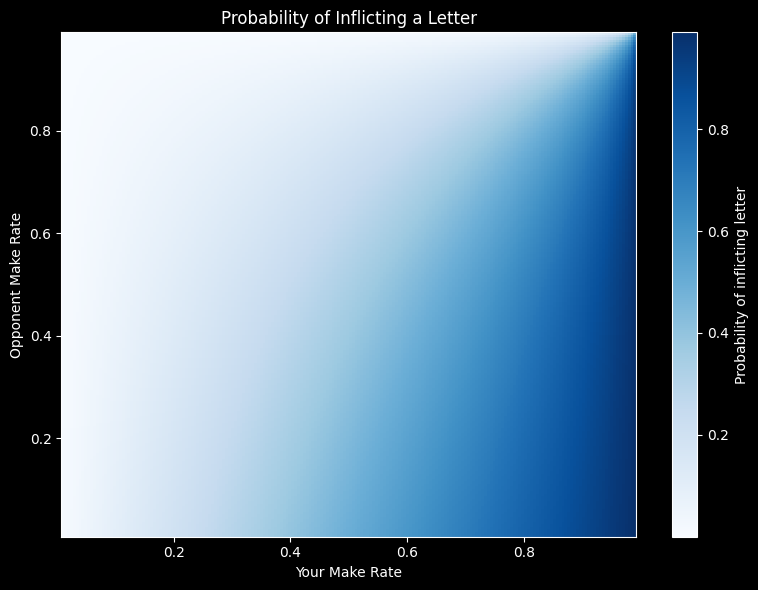

In [61]:
import matplotlib.pyplot as plt

# Visualize probability across the parameter space
plt.figure(figsize=(8, 6))
plt.pcolormesh(
    probability_df.columns, probability_df.index, probability_df,
     cmap='Blues'
)
plt.xlabel('Your Make Rate')
plt.ylabel('Opponent Make Rate')
plt.colorbar(label='Probability of inflicting letter')
plt.title('Probability of Inflicting a Letter')
plt.tight_layout()
plt.show()

Put simply, every possible shot corresponds to a point on this graph. The bluer the point, the more likely that shot is to result in a letter for your opponent.

Generally, a shot becomes more effective when you are better at making it and your opponent is worse at making it. But the make-it-take-it rules lead to an important insight: all else equal, an easier shot is always better. There is no point at which making a shot becomes "too easy." If you make it, you retain your turn and get another opportunity to shoot, even if your opponent also makes the shot. If you miss, however, your turn ends immediately.

This creates an interesting tradeoff. Although an easier shot is always preferable when the two players' abilities are unchanged, a harder shot can become more effective if it gives you a sufficiently large advantage over your opponent.

To explore the effects of comparative advantage more intuitively, we'll use the ratio of the two player's odds of making a given shot. Odds ratio is a better measure of relative advantage when the distinction between making and missing is what matters.

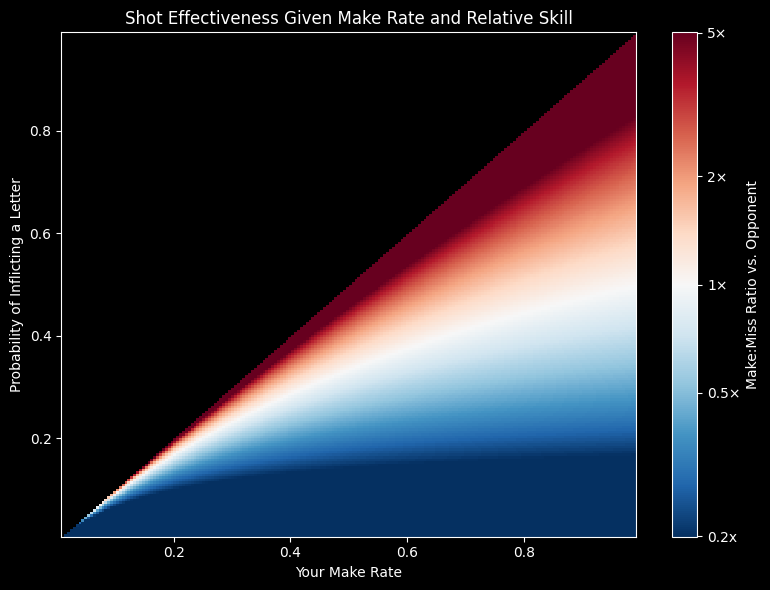

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameter grids
make_qs = np.linspace(0.01, 0.99, 200)
letter_qs = np.linspace(0.01, 0.99, 200)

x, y = np.meshgrid(make_qs, letter_qs)

# Required odds ratio:
with np.errstate(divide='ignore', invalid='ignore'):
    odds_ratio = (x * y) / (x - y)

# Impossible combinations: probability of giving a letter
# cannot exceed probability of making the initial shot
odds_ratio[y >= x] = np.nan

# Take log10 of odds ratio
log_odds_ratio = np.log10(odds_ratio)

# Plot
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    make_qs,
    letter_qs,
    log_odds_ratio,
    shading='auto',
    cmap='RdBu_r',
    vmin=-0.7,
    vmax= 0.7
)

plt.xlabel('Your Make Rate')
plt.ylabel('Probability of Inflicting a Letter')

cbar = plt.colorbar()
cbar.set_label('Make:Miss Ratio vs. Opponent')

# Make the tick labels more intuitive
cbar.set_ticks([np.log10(0.2), np.log10(0.5), 0, np.log10(2), np.log10(5)])
cbar.set_ticklabels(['0.2x','0.5×', '1×', '2×', '5×'])

plt.title('Shot Effectiveness Given Make Rate and Relative Skill')

plt.tight_layout()
plt.show()

Interestingly, comparative advantage doesn't actually make a large difference for harder shots. Meaning that being twice as good at a hard shot doesn't matter as much as being twice as good at an easy shot. For instance, if you and your opponent can both make an easy layup 18 out of 20 times, you'll inflict  a letter 47% of the time. But if you can get your ratio to 19 out of 20 times, you'll inflict a letter a whopping 65.5% of the time.

This simple model gives you few of takeaways to try in your next game of HORSE:
1. Choose shots that are easy for you, especially those which you are comparatively good at
2. Practice your favorite easy shot before the game
3. Goad your opponent into choosing hard shots

## Model 2: Unknown Probabilities

In reality, we don't actually know the make rate of ourself or our opponent. Both values have to be estimated from the information available to us. Bayesian inference gives us a principled way to do this by representing our uncertainty about these quantities and updating our beliefs as we observe more data.

This section takes us somewhat beyond what would be practical during a game of HORSE. The goal here isn't to suggest that a player should perform a full Bayesian analysis before every shot, but to understand what an ideal decision-making process would look like when we account for uncertainty. Later, we'll use these results to develop a simpler strategy that captures the important insights without requiring all of the computational machinery.

Suppose you don't know your true probability of making a free throw, but you think it's somewhere around 40%. You can represent this uncertainty with a Beta distribution, which is a great representation of probability because they both range between 0 and 1.

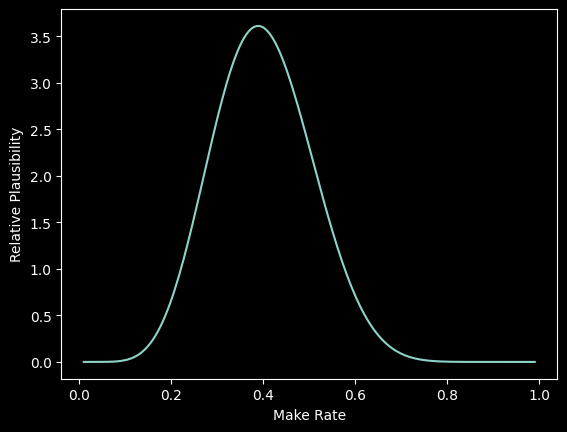

In [63]:
from scipy.stats import beta
from empiricaldist import Pmf

#our current beliefs, roughly 8 makes for every 12 misses, represented as a beta distribution
alpha_param = 8
beta_param = 12
free_throw_ps = beta.pdf(make_qs, alpha_param, beta_param)

#A labeled distribution assigning each possible make_rate to its relative plausibility
free_throw_prior = Pmf(free_throw_ps, make_qs)

#Plot
plt.plot(free_throw_prior)
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.show()

We can update our beliefs as we make or miss free throws. Each hypothesis (value on the x axis) becomes either more or less likely based on the evidence that comes in (makes and misses).

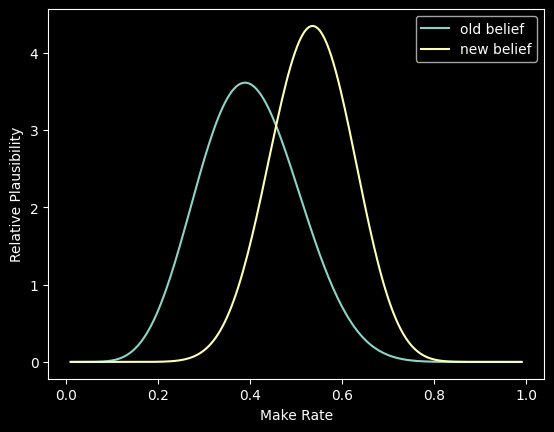

In [64]:
def update_beta(prior, data):
    """Return a new beta distribution given updated evidence"""
    makes, misses = data
    alpha_new = alpha_param + makes
    beta_new = beta_param + misses
    return Pmf(
        beta.pdf(prior.qs, alpha_new, beta_new),
        prior.qs
    )

#New evidence
makes = 8
misses = 2
data = (makes, misses)

#Update original distribution with new evidence
free_throw_updated = update_beta(free_throw_prior, data)

#Plot
plt.plot(free_throw_prior, label = 'old belief')
plt.plot(free_throw_updated, label = 'new belief')
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.legend()
plt.show()

We can also update our opponent's distribution by observing their makes and misses. For this example we'll assume our opponent had the same prior distribution as we did, but performed poorly.

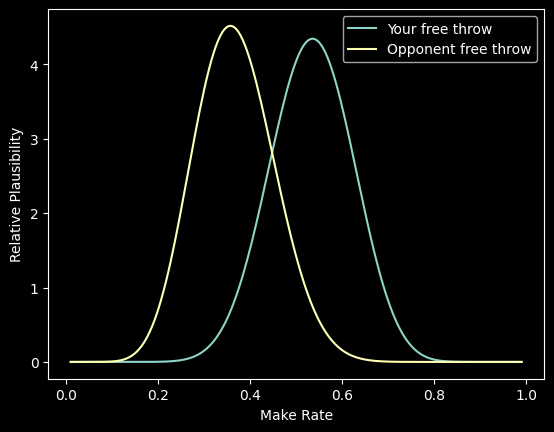

In [65]:
#You make 8 and miss 4
free_throw = update_beta(free_throw_prior, (8,2))

#Opponent makes 3 and misses 9
free_throw_opp = update_beta(free_throw_prior, (3,7))

#Plot
plt.plot(free_throw, label = 'Your free throw')
plt.plot(free_throw_opp, label = 'Opponent free throw')
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.legend()
plt.show()

We can plot the distributions in two dimensions to get a better understanding of the whole range of possibilities. Imagine placing these two distributions on perpendicular axes and looking at it from the top.

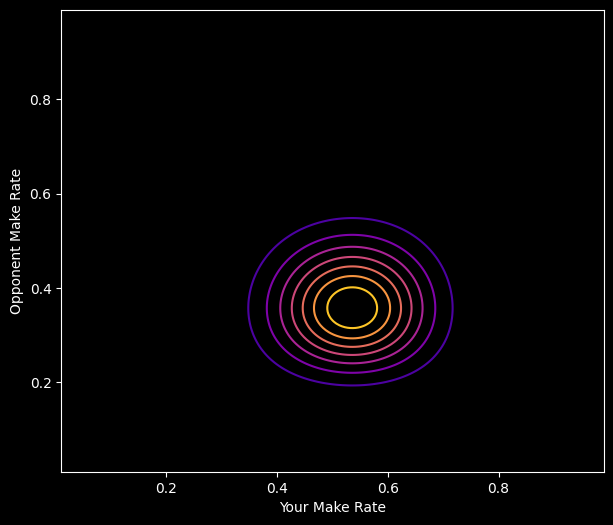

In [66]:
free_throw_pmf = Pmf(free_throw, make_qs)
free_throw_opp_pmf = Pmf(free_throw_opp, make_qs)

X,Y = np.meshgrid(free_throw.qs, free_throw_opp.qs)
data = np.outer(free_throw_opp.ps, free_throw.ps)

plt.figure(figsize=(7, 6))
plt.contour(X, Y, data, cmap = 'plasma')
plt.xlabel('Your Make Rate')
plt.ylabel('Opponent Make Rate')
plt.show()

This represents our uncertainty about both our make rate and our opponent's make rate.

Finally, we can overlay this  plot on the 'probability of inflicting a letter' plot from above to visualize how effective this shot might be in a real game.

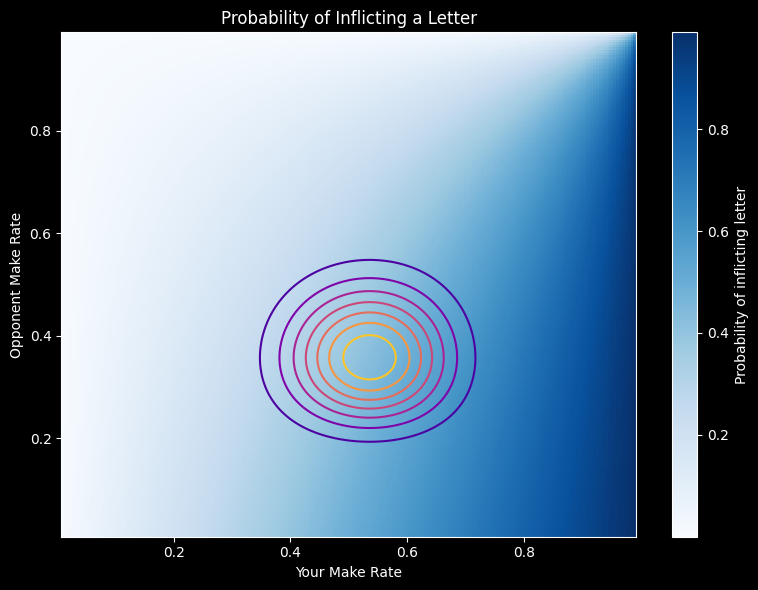

In [67]:
plt.figure(figsize=(8, 6))

#Proability of Inflicting a Letter Heatmap
plt.pcolormesh(
    probability_df.columns, probability_df.index, probability_df,
     cmap='Blues'
)

plt.xlabel('Your Make Rate')
plt.ylabel('Opponent Make Rate')
plt.colorbar(label='Probability of inflicting letter')
plt.title('Probability of Inflicting a Letter')
plt.tight_layout()

#Make rate distribution of free throws
plt.contour(X, Y, data, cmap = 'plasma')

plt.show()

All in all, this reflects the likelihood of a free throw inflicting a letter on our opponent, considering our uncertainty of the true make rates. While still fairly uncertain, a free throw seems to give us a decent chance of inflicting a letter.

Let's see what happens when we add some more shots to choose from. For the sake of example we're going to consider 4 different shots of increasing difficulty: layup, free throw, three-pointer, and hook. As before we have some idea of our ability to make each of them.

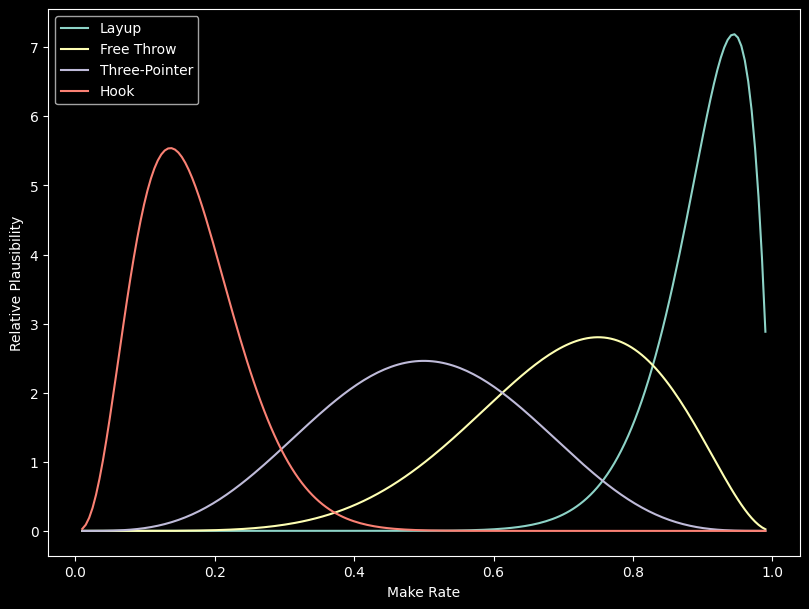

In [68]:
your_stats = {
    'Layup': {'makes': 18, 'misses': 2},
    'Free Throw': {'makes': 7, 'misses': 3},
    'Three-Pointer': {'makes': 5, 'misses': 5},
    'Hook': {'makes': 4, 'misses': 20}
}

def make_dist(stats):
    '''Make a distribution given shot'''
    makes = stats['makes']
    misses = stats['misses']
    return Pmf(beta.pdf(make_qs, makes, misses), make_qs)


plt.figure(figsize=(8, 6))

# plot each shot
for shot in your_stats.keys():
    plt.plot(make_dist(your_stats[shot]), label = shot)

plt.tight_layout()
plt.legend()
plt.xlabel('Make Rate')
plt.ylabel('Relative Plausibility')
plt.show()

We also don't know our opponents true rates. The most parsimonious assumption, in my opinion, is that they're similar to ours, but with wider ranges.

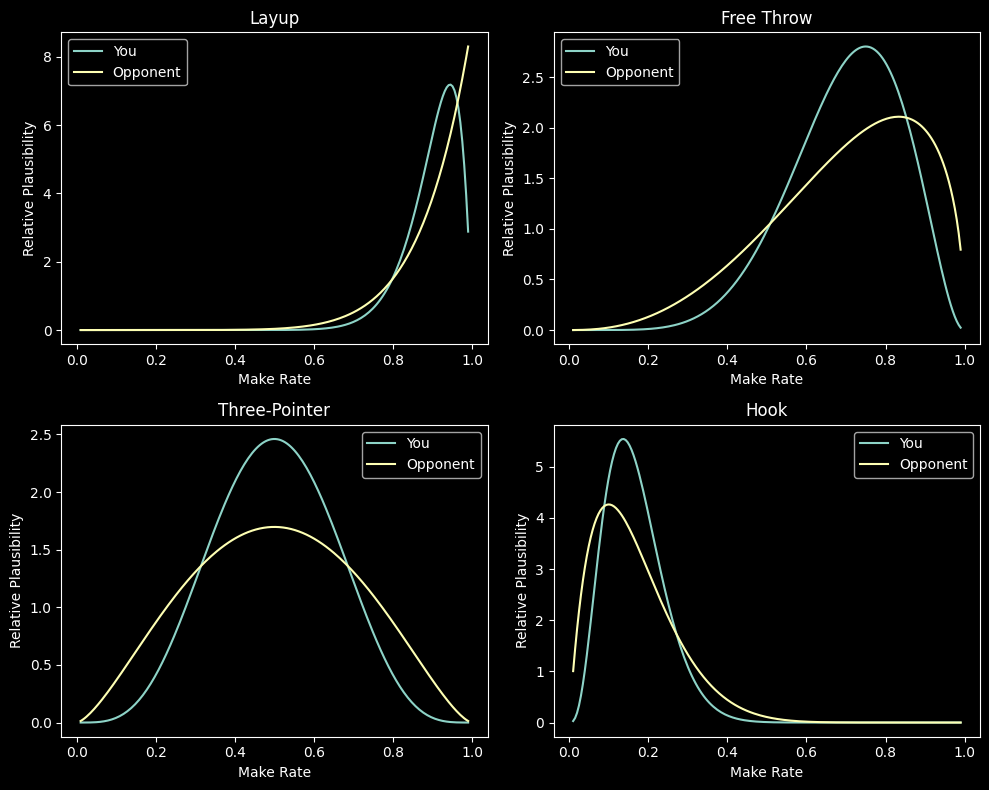

In [69]:
# prior distributions of opponent's shots - Parameters are all the same as ours but cut in half to represent less certainty
opp_stats = {
    'Layup': {'makes': 9, 'misses': 1},
    'Free Throw': {'makes': 3.5, 'misses': 1.5},
    'Three-Pointer': {'makes': 2.5, 'misses': 2.5},
    'Hook': {'makes': 2, 'misses': 10}
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#Plot both distribution for each shot, each in a seperate box
for ax, shot in zip(axes.flat, your_stats):
    ax.plot(make_dist(your_stats[shot]), label = 'You')
    ax.plot(make_dist(opp_stats[shot]), label = 'Opponent')
    ax.set_title(shot)
    ax.set_xlabel('Make Rate')
    ax.set_ylabel('Relative Plausibility')
    ax.legend()

plt.tight_layout()
plt.show()

For every shot, we can see how our opponent's shot distribution compares to ours.

We have distributions of both our and our opponent's make rates for each shot, but what does that mean for practical purposes? The final conceptual leap here is to translate each of these four pairs of distributions into a more informative distribution: the probability of inflicting a letter. We'll represent this graphically as well.

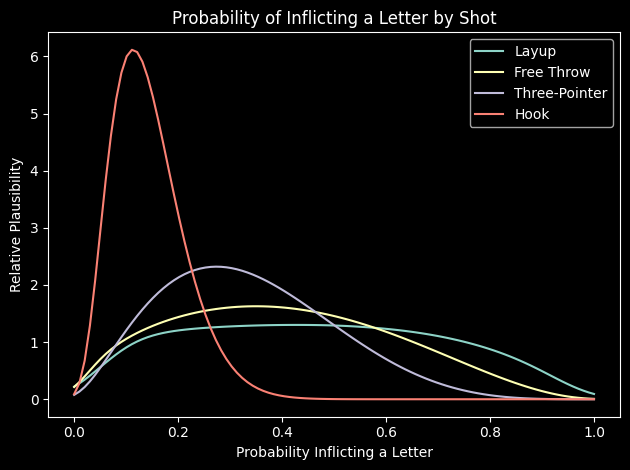

In [70]:
from scipy.stats import gaussian_kde

def plot_shot_effectiveness(stats = stats):
    for shot in stats['You'].keys():
        you = make_dist(stats['You'][shot])
        opp = make_dist(stats['Opponent'][shot])

        # Normalize probability so it sums to 1
        you_ps = you.ps / you.ps.sum()
        opp_ps = opp.ps / opp.ps.sum()

        # Find the probability of every combination of you vs. opponent make rate
        data = np.outer(you_ps, opp_ps)
        likelihoods = data.flatten()

        #weight probability of each combination by expected value of inflicting a letter
        probability_qs = np.linspace(0, 1, 100)
        game_value = probability_df.T.values.flatten()
        kde = gaussian_kde(
            game_value,
            weights=likelihoods)
        kde = kde(probability_qs)
        plt.plot(probability_qs, kde, label=shot)

    # plot outputs of function
    plt.title('Probability of Inflicting a Letter by Shot')
    plt.xlabel('Probability Inflicting a Letter')
    plt.ylabel('Relative Plausibility')
    plt.legend()
    plt.tight_layout()
    plt.show()

stats = {'You': your_stats, 'Opponent': opp_stats}
plot_shot_effectiveness(stats)

To summarize, we've defined distributions reflecting our prior beliefs about our and an unknown opponent's ability to make each of four shots. For each combination of parameters, we've scaled it up by the chance that it will inflict a letter. And we're left with the chance that each shot will inflict a letter. Conceptually, it's the same as the example before where we overlayed the 2D distribution on the heatmap and then judged how much 'blueness' was in that distribution.

Some shots appear more promising than others, but the distributions are wide enough that we cannot confidently identify a single “best” shot. For example, layups may currently have the highest expected probability of inflicting a letter, but there is still substantial uncertainty about whether free throws or three-pointers could ultimately be better. Always choosing the shot with the highest current estimate would therefore risk overlooking a shot that we simply have not learned enough about yet.

At the same time, exploration has a cost. Although it is technically possible that hook shots are the best option, our current beliefs make this very unlikely. Spending a large amount of time testing them would therefore be inefficient when there are other shots with much more promising potential.

This creates the classic exploration–exploitation tradeoff: we want to exploit shots that currently appear effective while continuing to explore shots that could plausibly be better. This is the fundamental problem addressed by multi-armed bandit algorithms.

We use Thompson sampling to balance these competing goals. In essence, we draw one random point under each curve and the point that is furthest along the x axis is chosen. Shots that are both promising and uncertain have a greater opportunity to be selected, while shots that are consistently unlikely to perform well are rarely chosen. As we collect more data, the distributions become narrower, allowing the algorithm to increasingly exploit the shots that the evidence supports.

In [71]:
def choose_shot_Thompson(stats = stats):
    '''return the name of the shot chosen by Thompson sampling'''

    samples = {}
    for shot in stats['You']:

        you = make_dist(stats['You'][shot])
        opp = make_dist(stats['Opponent'][shot])

        # normalize distributions
        you_ps = you.ps / you.ps.sum()
        opp_ps = opp.ps / opp.ps.sum()

        # weight every combination of make rate by 1. its likelihood and 2. its game value
        likelihood = np.outer(you_ps, opp_ps).flatten()
        game_value = probability_df.T.values.flatten()

        # select a random point from this weighted distribution
        sample = np.random.choice(
            game_value,
            p=likelihood / likelihood.sum()
        )

        samples[shot] = sample

    #return the shot with the highest selected point
    return max(samples, key=samples.get)

print('Chosen shot: ' + choose_shot_Thompson())

Chosen shot: Layup


Using this function we're close to finally simulating a whole game of HORSE. In this game, we'll choose shots with Thompson sampling the opponent will choose theirs randomly.


In [72]:
from scipy.stats import binom
import random

def shoot(player, shot):
    """ Simulate shooting, and update stats accordingly """
    #random chance to make the shot, given true probs
    made = binom.rvs(1, true_probs[player][shot])
    #update stats based on random draw
    if made == 1:
        stats[player][shot]['makes'] +=1
    else:
        stats[player][shot]['misses'] +=1
    return made


def your_turn():
    """ You choose shots with Thompson sampling until turn ends """
    while True:
        shot = choose_shot_Thompson()
        you_made = shoot('You', shot)
        if not you_made:
            return 'Opponent', 0
        opp_made = shoot('Opponent', shot)
        if not opp_made:
            return 'You', 1

def opp_turn():
    """ Opponent chooses shots randomly until they miss """
    while True:
        shot = random.choice(list(stats['Opponent'].keys()))
        opp_made = shoot('Opponent', shot)
        if not opp_made:
            return 'You', 0
        you_made = shoot('You', shot)
        if not you_made:
            return 'Opponent', 1

def full_game(turn = random.choice(['You', 'Opponent'])):
    """ Play a full game of HORSE """
    your_letters = 0
    opp_letters = 0
    while (your_letters < 5) and (opp_letters < 5):
        if turn == 'You':
            turn, letter = your_turn()
            if letter:
                opp_letters += 1
        else:
            turn, letter = opp_turn()
            if letter:
                your_letters += 1
    if your_letters == 5:
        return 0
    return 1


def set_stats(layup, freethrow, threepointer, hook, layup_opp, freethrow_opp, threepointer_opp, hook_opp):
    """ Set a dictionary of stats (make:miss tuples) to reflect beliefs before game """
    global stats
    stats = {
            'You':
                {
                'Layup': {'makes': layup[0], 'misses': layup[1]},
                'Free Throw': {'makes': freethrow[0], 'misses': freethrow[1]},
                'Three-Pointer': {'makes': threepointer[0], 'misses': threepointer[1]},
                'Hook': {'makes': hook[0], 'misses': hook[1]}
                },

            'Opponent':
                {
                'Layup': {'makes': layup_opp[0], 'misses': layup_opp[1]},
                'Free Throw': {'makes': freethrow_opp[0], 'misses': freethrow_opp[1]},
                'Three-Pointer': {'makes': threepointer_opp[0], 'misses': threepointer_opp[1]},
                'Hook': {'makes': hook_opp[0], 'misses': hook_opp[1]}
                }
            }

def set_true_probs(layup, freethrow, threepointer, hook, layup_opp, freethrow_opp, threepointer_opp, hook_opp):
    """ Set the actual probability of making a shot (our model doesn't know this value) """
    global true_probs

    true_probs = {
    'You': {'Layup': layup, 'Free Throw': freethrow, 'Three-Pointer': threepointer, 'Hook': hook},
    'Opponent': {'Layup': layup_opp, 'Free Throw': freethrow_opp, 'Three-Pointer': threepointer_opp, 'Hook': hook_opp}
    }

Using these functions, can simulate the results of 50 games pitting Thompson sampling vs. random shot selection.

10 wins out of 10


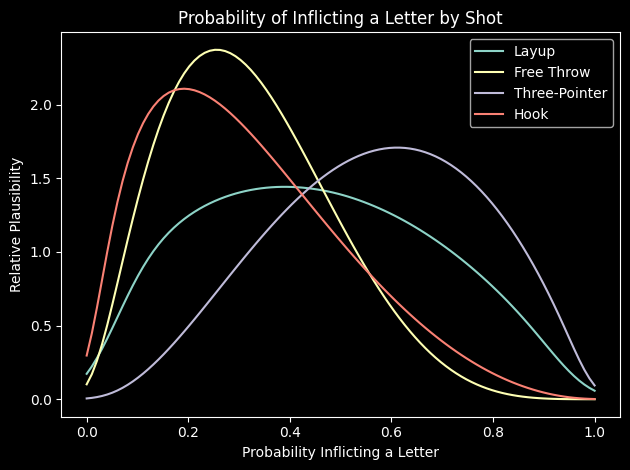

{'You': {'Layup': 0.89, 'Free Throw': 0.37, 'Three-Pointer': 0.61, 'Hook': 0.21}, 'Opponent': {'Layup': 0.93, 'Free Throw': 0.8, 'Three-Pointer': 0.52, 'Hook': 0.03}}


In [84]:
wins = 0
trials = 10

for i in range(trials):

    #reset priors beliefs - make them only vaguely informative
    set_stats((4,1),(2,1),(1,1),(1,2),(2,0.5),(1,0.5),(0.5,0.5),(0.5,1))

    #randomly assign true probabilities for each game,
    set_true_probs(round(np.random.beta(12, 3), 2), round(np.random.beta(6, 3), 2), round(np.random.beta(3,3), 2), round(np.random.beta(3,6), 2), round(np.random.beta(12,3), 2), round(np.random.beta(6,3),2), round(np.random.beta(3,3),2), round(np.random.beta(3,6), 2))
    wins+=full_game()



print(str(wins) + ' wins out of ' + str(trials))

#uncomment the functions below to see what you learned throughout the last game:

plot_shot_effectiveness(stats)
print(true_probs)

In the simulation above, we win about 2 of 3 games in the long run.

The current assumptions are relatively conservative:
1. we and the opponent are relatively evenly matched,
2. our skills come from the same, somewhat predictable, distribution, and
3. we only have a very hazy initial idea of the make rates.

## Sensitivity, Robustness, and Computational Efficiency

Currently, this shot-selection model works reasonably well. In this last section, we'll put this model through a stress-test, seeing if we still retain the advantage when we change the assumptions and conditions of the game.

We'll also explore some simpler strategies that can be used in a real game, and see if we can get close to the results of the Bayesian model above.

Next sections:
- Model 3: back to the real world
- in this section we’ll Use simulation to test the efficacy of different strategies in random games.
- formulate a few computationally simple strategies. for one, just do blindly do easy shots
- simulate games with these strategies against a fixed opponent. compare long run win rate. quanitfy how much we lose by choosing computationally simpler strategies
- robustness analysis
    - Test these strategies against a widening parameters of opponents, including the underlying parameters that decide the distribution of mu and sigma values
    - conduct 3-5 different categories of simulation, all adding more variation in opponent distribution including
        - underlying comparative advantage multiplier (fixed ‘mean’)
        - variation in comparative advantage among shots (‘variation’)
        - variation in variation in comparative advantage (‘skewness’)
    - get posterior marginal win rates as I increase heterogeneity
        - see how these distributions shift as these parameters are all toned up
        - as these assumptions purturb, does the optimal strategy change?
                -
                        -
- Presumably, the win rate would increase if
1. We played multiple games in a row, keeping all the information between games
2. Our comparative skillset vs. the opponent was more heterogeneous, giving us more advantages to exploit.


later on
- bonus: HORSE with 3 people. simulate games with a different, fixed shot selection for each one to quantify win rate for simulated 3 person HORSE. and reconstruct heatmap of strategies.
    - siumulaation allows us to test different strategies in 3 person HORSE even though its nearly impossible for me to ‘solve’
- add a pretty animation that demonstrates the rules of the game (EVENTUALLY)

## Issues with the Model

This models makes for a good case study; we got to see some interesting techniques. but as with any model, it's not perfect: far from it, in fact.

We try to maximize the probability of inflicting a letter, which is not exactly the same as the probability of winning the entire game. Although it's worth mentioning that for a 1v1 matchup, these two metrics lead to identical decisions.

We use a beta distribution to represent probabilities of making a shot, but it gets imprecise in upper ranges as 98% make rate is only slightly more plausible than 99%, but in reality 99% is much harder to acheive and much less plausible.